# Figure S6d–h — Axodendritic synapse distance to its nearest axoaxonic synapse

For every axodendritic synapse, the **cable-length distance along the axon to the nearest
axoaxonic synapse**. A peak at zero means the two synapse types are co-localized: the
GABAergic input sits right where the sensory neuron drives its postsynaptic partners.

One histogram per subtype, using the **2 axons per subtype with manually validated
axoaxonic synapses**:

| Panel | Subtype |
| --- | --- |
| **d** | Aβ-LTMR |
| **e** | Aδ-LTMR |
| **f** | C-LTMR |
| **g** | C-HTMR/Heat (MrgprD, MrgprA3, MrgprB4) |
| **h** | Aδ-HTMR, split into dorsal and ventral terminal branches |

Panel h splits each Aδ-HTMR's axodendritic synapses by the y coordinate of the synapse
(`Y_SPLIT`), because these axons span laminae I–IV and the two territories differ in how
much presynaptic inhibition they receive.

**Input.** `../data/meshwork_h5/*.h5`. **Runs offline — no CAVE access.**


In [1]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.size"] = 6

CM = 1 / 2.54


In [2]:
# Internal tag -> published label, and the Figure 3 / S6 colour scheme.
SUBTYPE_LABELS = {
    "ab-ltmr":  "Aβ-LTMR",
    "adltmr":   "Aδ-LTMR",
    "cltmr":    "C-LTMR",
    "mrgd":     "C-HTMR/Heat (MrgprD,MrgprA3,MrgprB4)",
    "sst":      "C-HTMR/Heat (SST)",
    "ad-htmr":  "Aδ-HTMR",
    "c-htmr-p": "Peptidergic C-nociceptor",
    "C-COLD":   "C-Cold",
}

PALETTE = {
    "Aβ-LTMR":                              "#556B2F",
    "Aδ-LTMR":                              "#00A86B",
    "C-LTMR":                               "#BCEBCB",
    "C-HTMR/Heat (MrgprD,MrgprA3,MrgprB4)": "#b23aee",
    "C-HTMR/Heat (SST)":                    "#ffbbff",
    "Aδ-HTMR":                              "#ff4040",
    "Peptidergic C-nociceptor":             "#ffee00",
    "C-Cold":                               "#00bfff",
}

SUBTYPE_ORDER = ["ab-ltmr", "adltmr", "cltmr", "mrgd", "sst",
                 "ad-htmr", "c-htmr-p", "C-COLD"]


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
from meshparty import meshwork

H5_DIR = Path("../data/meshwork_h5")
SUBTYPE_CSV = Path("../data/meshwork_h5_subtypes.csv")
NM_TO_UM = 1e-3


def load(coord, subdir=""):
    """Load one meshwork .h5 by its 'x_y_z' coordinate string."""
    return meshwork.load_meshwork(H5_DIR / subdir / f"{coord}.h5")


def syn_indices(neuron):
    """Mesh indices of axodendritic and axoaxonic synapses.

    The sensory neuron is the reference cell in these meshwork files, so
    `pre_syn` = synapses it makes onto dendrites (axodendritic) and
    `post_syn` = synapses made onto it (axoaxonic).
    """
    pre = getattr(neuron.anno, "pre_syn", None)
    post = getattr(neuron.anno, "post_syn", None)
    return (np.asarray([] if pre is None else pre.mesh_index, dtype=int),
            np.asarray([] if post is None else post.mesh_index, dtype=int))


def distance_to_tips_um(neuron, idx):
    """Path distance (µm) from each synapse to its nearest axon tip."""
    tips = neuron.end_points
    if len(idx) == 0 or len(tips) == 0:
        return np.array([])
    return np.min(neuron.distance_between(idx, tips), axis=1) * NM_TO_UM


/Users/wangchu/opt/anaconda3/lib/python3.8/site-packages/python_jsonschema_objects/__init__.py:113: UserWarning: Schema id not specified. Defaulting to 'self'
  warnings.warn("Schema id not specified. Defaulting to 'self'")


In [4]:
# The 16 axons (2 per subtype) whose axoaxonic synapses were manually validated.
# Keys are the 'x_y_z' coordinates that name the .h5 files.
VALIDATED_COORDS = {
    "cltmr":    ["8833_3005_124", "4269_2367_2029"],
    "mrgd":     ["20373_3883_152", "24101_2062_2511"],
    "adltmr":   ["30150_8985_113", "31400_8361_125"],
    "ab-ltmr":  ["32620_7875_114", "20015_10209_299"],
    "sst":      ["5177_3371_3247", "4368_5433_963"],
    "ad-htmr":  ["27406_7510_125", "12791_2154_609"],
    "c-htmr-p": ["4146_2804_1486", "6795_4315_137"],
    "C-COLD":   ["16255_2088_2735", "5500_2063_1184"],
}


In [5]:
def distance_to_nearest_um(neuron, idx_from, idx_to):
    """Path distance (µm) from each `idx_from` synapse to the nearest `idx_to` synapse."""
    if len(idx_from) == 0 or len(idx_to) == 0:
        return np.array([])
    return np.min(neuron.distance_between(idx_from, idx_to), axis=1) * NM_TO_UM


In [6]:
MAX_DIST_UM = 20.0
N_BINS = 30
bins = np.linspace(0, MAX_DIST_UM, N_BINS + 1)

# Panels d-g: one subtype each.
PANELS = {"d": "ab-ltmr", "e": "adltmr", "f": "cltmr", "g": "mrgd"}

distances = {}
for panel, tag in PANELS.items():
    vals = []
    for coord in VALIDATED_COORDS[tag]:
        neuron = load(coord)
        pre_idx, post_idx = syn_indices(neuron)
        d = distance_to_nearest_um(neuron, pre_idx, post_idx)
        if d.size:
            vals.append(d)
    distances[panel] = np.concatenate(vals) if vals else np.array([])
    print(f"panel {panel}  {SUBTYPE_LABELS[tag]:40s} "
          f"{distances[panel].size:5d} axodendritic synapses"
          f"   within 5 µm: {np.mean(distances[panel] <= 5):5.1%}")


panel d  Aβ-LTMR                                   4337 axodendritic synapses   within 5 µm: 91.5%
panel e  Aδ-LTMR                                   6922 axodendritic synapses   within 5 µm: 97.7%
panel f  C-LTMR                                    5323 axodendritic synapses   within 5 µm: 86.5%
panel g  C-HTMR/Heat (MrgprD,MrgprA3,MrgprB4)      3057 axodendritic synapses   within 5 µm: 74.1%


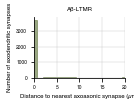

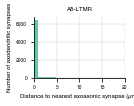

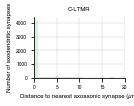

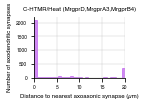

In [7]:
import matplotlib.pyplot as plt

for panel, tag in PANELS.items():
    data = distances[panel]
    if data.size == 0:
        continue
    label = SUBTYPE_LABELS[tag]
    colour = PALETTE[label]

    fig, ax = plt.subplots(figsize=(5.0 * CM, 4.0 * CM))
    ax.hist(np.clip(data, 0, MAX_DIST_UM), bins=bins, histtype="stepfilled",
            linewidth=0.8, edgecolor=colour, facecolor=colour, alpha=0.6)
    ax.set_xlim(0, MAX_DIST_UM)
    ax.set_xlabel("Distance to nearest axoaxonic synapse (µm)", fontsize=6)
    ax.set_ylabel("Number of axodendritic synapses", fontsize=6)
    ax.set_title(label, fontsize=6)
    ax.tick_params(labelsize=5)
    ax.grid(True, lw=0.3)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    fig.tight_layout()
    fig.savefig(f"figureS6{panel}_{tag}_distance_to_nearest_axoaxonic.svg",
                format="svg", dpi=300)
    plt.show()


Aδ-HTMR dorsal:   1145 axodendritic synapses   within 5 µm of an axoaxonic synapse: 53.4%
Aδ-HTMR ventral:   135 axodendritic synapses   within 5 µm of an axoaxonic synapse: 51.1%


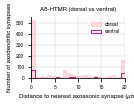

In [8]:
# ---- panel h: Aδ-HTMR, dorsal vs ventral terminal branches
Y_SPLIT = 140_800          # nm; mesh y coordinate separating dorsal from ventral
LAYER_COLOURS = {"dorsal": "#ffb6c1", "ventral": "#c71585"}

dorsal, ventral = [], []
for coord in VALIDATED_COORDS["ad-htmr"]:
    neuron = load(coord)
    pre_idx, post_idx = syn_indices(neuron)
    d = distance_to_nearest_um(neuron, pre_idx, post_idx)
    if d.size == 0:
        continue
    pre_y = neuron.mesh.vertices[pre_idx][:, 1]
    dorsal.append(d[pre_y <= Y_SPLIT])
    ventral.append(d[pre_y > Y_SPLIT])

dorsal = np.concatenate(dorsal) if dorsal else np.array([])
ventral = np.concatenate(ventral) if ventral else np.array([])
print(f"Aδ-HTMR dorsal:  {dorsal.size:5d} axodendritic synapses"
      f"   within 5 µm of an axoaxonic synapse: {np.mean(dorsal <= 5):5.1%}")
print(f"Aδ-HTMR ventral: {ventral.size:5d} axodendritic synapses"
      f"   within 5 µm of an axoaxonic synapse: {np.mean(ventral <= 5):5.1%}")

fig, ax = plt.subplots(figsize=(5.0 * CM, 4.0 * CM))
if dorsal.size:
    ax.hist(np.clip(dorsal, 0, MAX_DIST_UM), bins=bins, histtype="stepfilled",
            alpha=0.5, edgecolor=LAYER_COLOURS["dorsal"],
            facecolor=LAYER_COLOURS["dorsal"], label="dorsal")
if ventral.size:
    ax.hist(np.clip(ventral, 0, MAX_DIST_UM), bins=bins, histtype="step",
            linewidth=1.0, edgecolor=LAYER_COLOURS["ventral"], label="ventral")

ax.set_xlim(0, MAX_DIST_UM)
ax.set_xlabel("Distance to nearest axoaxonic synapse (µm)", fontsize=6)
ax.set_ylabel("Number of axodendritic synapses", fontsize=6)
ax.set_title("Aδ-HTMR (dorsal vs ventral)", fontsize=6)
ax.tick_params(labelsize=5)
ax.grid(True, lw=0.3)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(fontsize=5, frameon=False)
fig.tight_layout()
fig.savefig("figureS6h_adhtmr_dorsal_ventral_distance_to_nearest_axoaxonic.svg",
            format="svg", dpi=300)
plt.show()
